Dataset: kaggle.com/datasets/yasserh/housing-prices-dataset 

1. Load Housing.csv. Print .shape, .dtypes, .isnull().sum(), and .describe(). 

2. Plot a histogram of price. Is it skewed? 

3. Compute .corr() on numeric columns. Which feature correlates most with price? 

4. Plot a boxplot of price grouped by stories.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
df.shape

(545, 13)

In [4]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [5]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


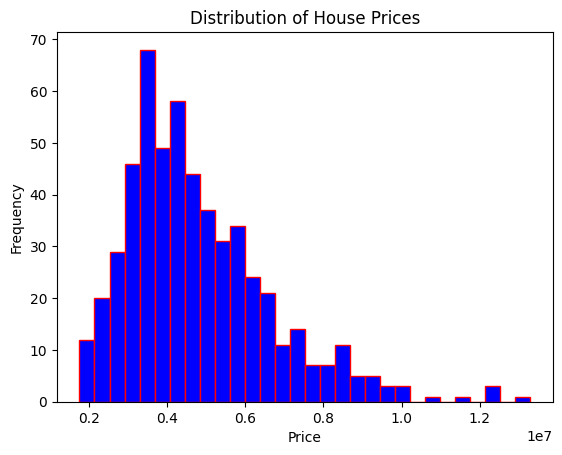

In [7]:
plt.hist(df["price"],bins=30,color="blue",edgecolor="red")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

In [22]:
numeric_columns=['price','area','bedrooms','bathrooms','stories','parking']
df[numeric_columns].corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

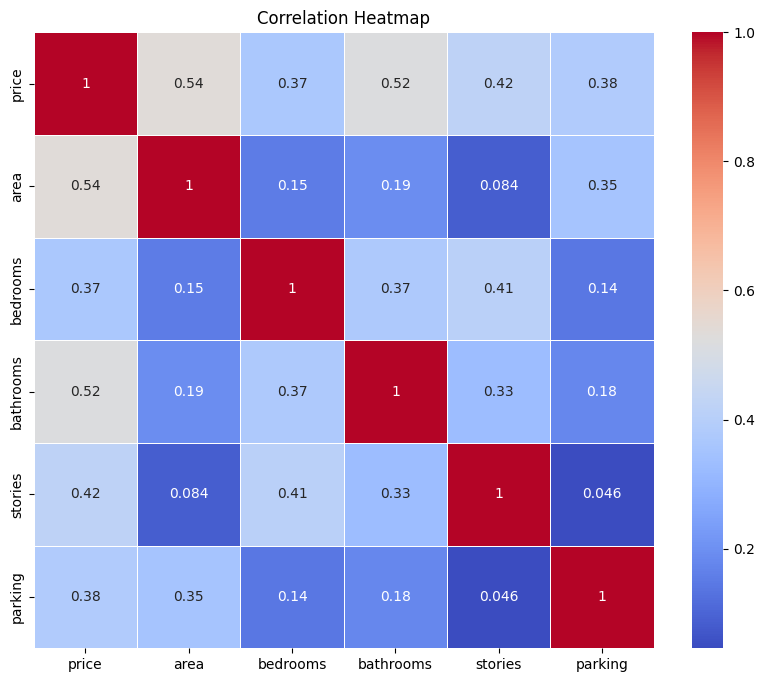

In [23]:
#Compute .corr() on numeric columns. Which feature correlates most with price? 
numeric_columns=['price','area','bedrooms','bathrooms','stories','parking']
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_columns].corr(),annot=True,cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")

<Axes: ylabel='price'>

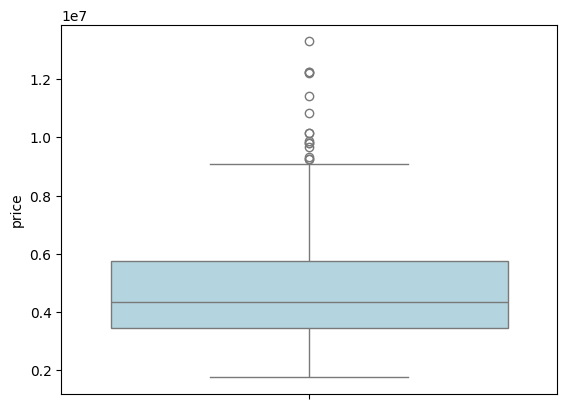

In [24]:
sns.boxplot(data=df['price'],color="lightblue")

# 2. Feature Engineering via Pipeline & ColumnTransformer 

 
1. Split data: X = all features, y = price. Use train_test_split. 

2. List your numeric columns in a variable called numeric_features. 

3. Build a numeric_pipeline: steps = [SimpleImputer(median), StandardScaler()]. 

4. Build a column_pipeline 

5. Wrap it in ColumnTransformer(transformers=[('num', numeric_pipeline, 
numeric_features)]). 

6. Call preprocessor.fit_transform(X_train) and .transform(X_test). Print the output shape. 

In [ ]:
#1. Split data: X = all features, y = price. Use train_test_split. 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


x=df.drop('price',axis=1)
y=df['price']

#2. List your numeric columns in a variable called numeric_features. 
numeric_features=['area','bedrooms','bathrooms','stories','parking']

#3. Build a numeric_pipeline: steps = [SimpleImputer(median), StandardScaler()].
numeric_pipeline=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
    
])

#4. Build a column_pipeline 
categorical_columns=['mainroad','guestroom','basement','hotwaterheating','airconditioning', 'prefarea','furnishingstatus']

categorical_pipeline=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(drop='first'))
])

from sklearn.compose import ColumnTransformer
processor=ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_columns)
])

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)



# 3. Train LinearRegression & SGDRegressor (using Pipeline) 




 
1. Build lr_pipeline = Pipeline([('preprocessor', preprocessor), ('model', 
LinearRegression())]). 
2. Fit lr_pipeline on X_train, y_train. Print .coef_ and .intercept_. 
3. Build sgd_pipeline the same way but use SGDRegressor(random_state=42). 
4. Fit sgd_pipeline on X_train, y_train. Print .coef_ and .intercept_. 
5. Generate predictions for both models on X_train and X_test. 

In [45]:
#linear regression
from sklearn.linear_model import LinearRegression,SGDRegressor
lr_pipeline=Pipeline(steps=[
    ("processor",processor),
    ("lr",LinearRegression())
])
lr_pipeline.fit(X_train,y_train)
y_pred=lr_pipeline.predict(X_test)
y_pred

array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.3272256 , 3294646.25725956, 3532275.09556558,
       5611774.56836475, 6368145.98732718, 2722856.95689986,
       2629405.61585783, 9617039.50315579, 2798087.30447888,
       3171096.76847064, 3394639.09125528, 3681088.65424275,
       5263187.74621486, 3035963.47612385, 4786122.8004005 ,
       4349551.9200572 , 3572362.09930451, 5774875.21395649,
       5886993.57919883, 2730836.19518458, 4727316.47323636,
       5244847.52716799, 7555324.21605601, 3220790.84680269,
       5191898.79934207, 8143726.91009782, 3398814.09825035,
       6490693.05027925, 3315105.90747811, 6708457.36761325,
       4201738.21071675, 3557571.06735186, 5836974.50478626,
       4808660.67448475, 4362878.73613262, 3191242.95701508,
       4596554.93225239, 4566042.8604841 , 3517779.52374149,
       7205844.79365835, 3983597.27861103, 3749338.70271055,
       4274731.09125895, 6757442.1078374 , 4037320.43665852,
       3769334.90397125,

# 4. Evaluation Metrics — RMSE, MAE, R² 
 
1. Compute RMSE, MAE, R² for LinearRegression on both train and test sets. 
2. Compute the same metrics for SGDRegressor. 
3. Print all results in one table using a pandas DataFrame.

In [49]:
import numpy as np
from sklearn.metrics import mean_squared_error,r2_score

sgd_pipeline=Pipeline(steps=[
    ('processor', processor),
    ('sgd', SGDRegressor())
    
])
sgd_pipeline.fit(X_train,y_train)
y_pred_sgd=sgd_pipeline.predict(X_test)


mse=mean_squared_error(y_test,y_pred_sgd)
print(f"Mean Squared Error: {mse}")
r2=r2_score(y_test,y_pred_sgd)
print(f"R^2 Score: {r2}")

rmse=np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse}")


Mean Squared Error: 1734186665548.744
R^2 Score: 0.6569071986292616
Root Mean Squared Error: 1316885.2135052409


# 5. Compare Both Models 
 
1. Which model has lower Test RMSE — LinearRegression or SGDRegressor? 
2. Is Train R² much higher than Test R²?   
If yes, the model may be overfitting. Learn about Overfitting and Underfitting 

In [50]:
#Which model has lower Test RMSE — LinearRegression or SGDRegressor? 
mse_lr=mean_squared_error(y_test,y_pred)
rmse_lr=np.sqrt(mse_lr)
print(f"Linear Regression RMSE: {rmse_lr}")
mse_sgd=mean_squared_error(y_test,y_pred_sgd)

rmse_sgd=np.sqrt(mse_sgd)
print(f"SGD Regressor RMSE: {rmse_sgd}")

if rmse_lr < rmse_sgd:
    print("Linear Regression has lower Test RMSE.")
else:
    print("SGD Regressor has lower Test RMSE.")

Linear Regression RMSE: 1324506.96009144
SGD Regressor RMSE: 1316885.2135052409
SGD Regressor has lower Test RMSE.


In [52]:
#Is Train R² much higher than Test R²?   
#If yes, the model may be overfitting. Learn about Overfitting and Underfitting 
y_train_pred=lr_pipeline.predict(X_train)
r2_train=r2_score(y_train,y_train_pred)
print(f"Train R^2: {r2_train}")
r2_test=r2_score(y_test,y_pred)
print(f"Test R^2: {r2_test}")

 

Train R^2: 0.6859438988560158
Test R^2: 0.6529242642153177
